# Test Overlap Region Finding (Approach B)

Tests the intersection-centered line-fitting algorithm on one bow-tie boundary
from the development `latlon.mat` data.

**Algorithm steps:**
1. Find the column where two scan lines cross (delta_lat sign change)
2. Center a w=30 pixel window on the crossing
3. Fit a reference line through the leading scan (equirectangular OLS)
4. Compute perpendicular distance from the trailing scan to the line
5. Normalize by pixel spacing: q = |d_perp| / pixel_spacing
6. Overlap region = contiguous columns where q < q_max (1%)

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

# Add module path
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'py'))
from modis_matchups import load_latlon, reshape_to_bowties, haversine, N_PIXELS
from find_regions import (
    find_intersection, fit_line, perp_distance,
    compute_pixel_spacing, find_region_one_side,
    find_regions_one_boundary, equirect_project,
    DETECTOR_PAIRS, NADIR_COL
)

FIG_DIR = '/home/xavier/Projects/overleaf/modis-correct'
os.makedirs(FIG_DIR, exist_ok=True)

%matplotlib inline

In [2]:
# Load data and reshape into bow-ties
data_file = os.path.join('..', 'data', 'latlon.mat')
lat, lon = load_latlon(data_file)
lat_bt, lon_bt, n_skip = reshape_to_bowties(lat, lon)
print(f'{lat_bt.shape[0]} complete bow-ties, skipped {n_skip} lines')
print(f'Bow-tie array shape: {lat_bt.shape}')

4026 complete bow-ties, skipped 5 lines
Bow-tie array shape: (4026, 10, 1354)


In [3]:
# Pick a bow-tie boundary and a demo detector pair
k = 900  # boundary near equator for clear geometry
det_i, det_j = 10, 1  # trailing D10 from B_k, leading D1 from B_{k+1}
w = 30       # window width
q_max = 0.05 # 5% of pixel spacing

# Extract scan lines
lat_meas = lat_bt[k, det_i - 1, :]     # D10 of B_k (trailing, measured)
lon_meas = lon_bt[k, det_i - 1, :]
lat_ref = lat_bt[k + 1, det_j - 1, :]  # D1 of B_{k+1} (leading, reference)
lon_ref = lon_bt[k + 1, det_j - 1, :]

print(f'Boundary k={k}: D{det_i}(B_{k}) vs D{det_j}(B_{k+1})')
print(f'Lat range: {lat_ref.min():.3f} to {lat_ref.max():.3f}')
print(f'Lon range: {lon_ref.min():.3f} to {lon_ref.max():.3f}')

Boundary k=900: D10(B_900) vs D1(B_901)
Lat range: -3.344 to -0.372
Lon range: 1.846 to 22.552


## Step 1: Find the Scan-Line Intersection

Compute the latitude difference (proxy for along-track displacement) between the trailing
scan (D10 of B_k) and the reference scan (D1 of B_{k+1}). Where it changes sign, the
scan lines cross. We process each side of nadir independently.

Left  crossing: P = 363.0
Right crossing: P = 969.0


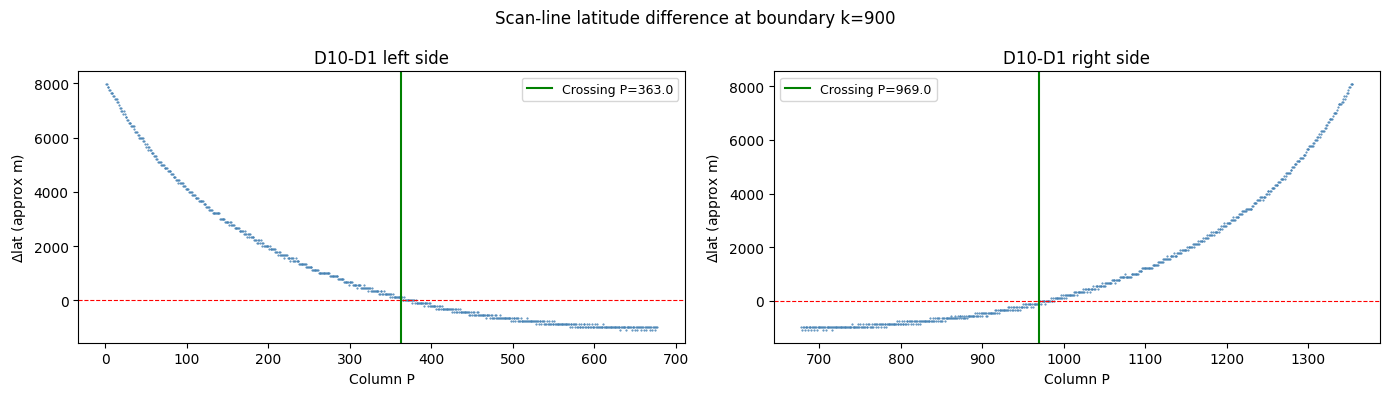

In [4]:
# Compute delta_lat on both sides of nadir
left_cols = np.arange(0, NADIR_COL)       # 0-indexed: 0..676
right_cols = np.arange(NADIR_COL, N_PIXELS) # 0-indexed: 677..1353

delta_left = lat_meas[left_cols] - lat_ref[left_cols]
delta_right = lat_meas[right_cols] - lat_ref[right_cols]

# Find intersections
cross_left = find_intersection(lat_ref, lon_ref, lat_meas, lon_meas, left_cols)
cross_right = find_intersection(lat_ref, lon_ref, lat_meas, lon_meas, right_cols)

print(f'Left  crossing: P = {cross_left + 1:.1f}' if cross_left is not None else 'Left  crossing: None')
print(f'Right crossing: P = {cross_right + 1:.1f}' if cross_right is not None else 'Right crossing: None')

# Plot delta_lat vs column
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(left_cols + 1, delta_left * 111_000, '.', ms=1, color='steelblue')
axes[0].axhline(0, color='red', ls='--', lw=0.8)
if cross_left is not None:
    axes[0].axvline(cross_left + 1, color='green', lw=1.5,
                    label=f'Crossing P={cross_left + 1:.1f}')
axes[0].set_xlabel('Column P')
axes[0].set_ylabel('$\\Delta$lat (approx m)')
axes[0].set_title(f'D{det_i}-D{det_j} left side')
axes[0].legend(fontsize=9)

axes[1].plot(right_cols + 1, delta_right * 111_000, '.', ms=1, color='steelblue')
axes[1].axhline(0, color='red', ls='--', lw=0.8)
if cross_right is not None:
    axes[1].axvline(cross_right + 1, color='green', lw=1.5,
                    label=f'Crossing P={cross_right + 1:.1f}')
axes[1].set_xlabel('Column P')
axes[1].set_ylabel('$\\Delta$lat (approx m)')
axes[1].set_title(f'D{det_i}-D{det_j} right side')
axes[1].legend(fontsize=9)

plt.suptitle(f'Scan-line latitude difference at boundary k={k}', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'region_intersection.png'), dpi=150)
plt.show()

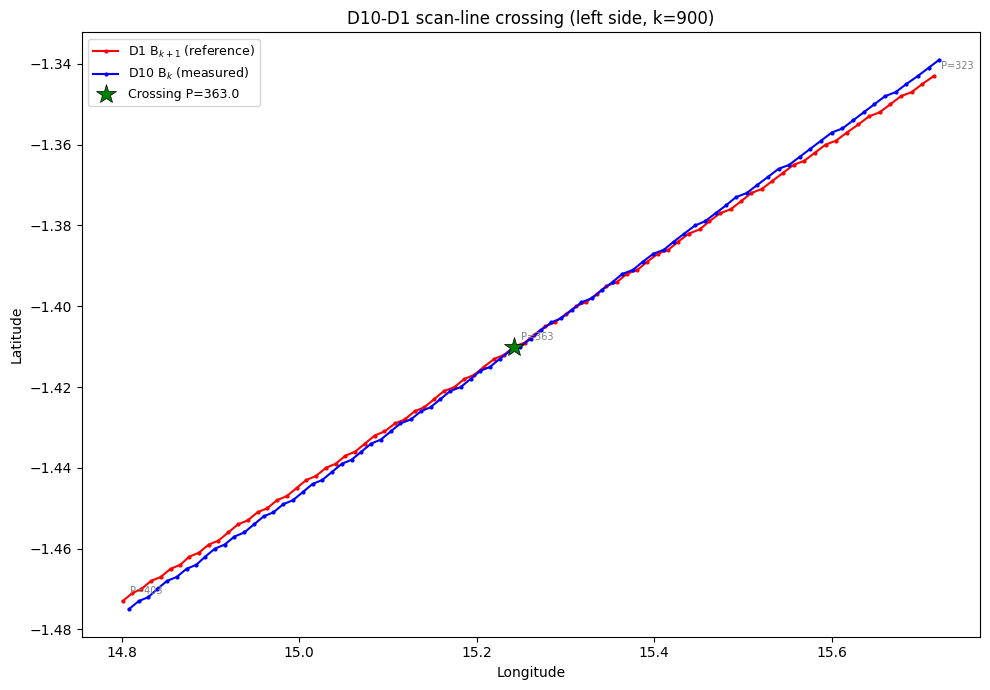

In [5]:
# Figure: Two scan lines in lat/lon space, zoomed to the crossing region
if cross_left is not None:
    cx = int(round(cross_left))
    zoom = 40  # columns on each side
    c0 = max(0, cx - zoom)
    c1 = min(N_PIXELS - 1, cx + zoom)
    cols_zoom = np.arange(c0, c1 + 1)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.plot(lon_ref[cols_zoom], lat_ref[cols_zoom],
            '.-', ms=4, color='red', label=f'D{det_j} B$_{{k+1}}$ (reference)')
    ax.plot(lon_meas[cols_zoom], lat_meas[cols_zoom],
            '.-', ms=4, color='blue', label=f'D{det_i} B$_k$ (measured)')

    # Mark the crossing point (interpolated)
    from scipy.interpolate import interp1d
    lat_ref_interp = interp1d(np.arange(N_PIXELS), lat_ref)(cross_left)
    lon_ref_interp = interp1d(np.arange(N_PIXELS), lon_ref)(cross_left)
    ax.plot(lon_ref_interp, lat_ref_interp, '*', ms=15, color='green',
            markeredgecolor='black', markeredgewidth=0.5,
            label=f'Crossing P={cross_left + 1:.1f}', zorder=5)

    # Annotate a few column numbers
    for p in [c0, cx, c1]:
        ax.annotate(f'P={p+1}', (lon_ref[p], lat_ref[p]),
                    textcoords='offset points', xytext=(5, 5), fontsize=7, color='gray')

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'D{det_i}-D{det_j} scan-line crossing (left side, k={k})')
    ax.legend(fontsize=9)
    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, 'region_scanline_crossing.png'), dpi=150)
    plt.show()
else:
    print('No crossing on left side to plot.')


## Step 2: Fit Reference Line and Compute Quality

For one side (left), fit the reference line through D1 of B_{k+1} in a w=30 window
centered on the crossing point. Then compute perpendicular distance from D10 of B_k,
normalize by pixel spacing to get q(P), and identify the overlap region where q < 1%.

In [6]:
# Run the full algorithm for D10-D1, left side
result_left = find_region_one_side(
    lat_ref, lon_ref, lat_meas, lon_meas,
    left_cols, w=w, q_max=q_max)

if result_left is not None:
    print(f'Overlap region: P = {result_left["cols_P"][0]} to {result_left["cols_P"][-1]}')
    print(f'  Width: {len(result_left["cols"])} columns')
    print(f'  Crossing at P = {result_left["cross_col_P"]:.1f}')
    print(f'  q range: [{result_left["q"].min():.5f}, {result_left["q"].max():.5f}]')
    print(f'  |d_perp| range: [{np.abs(result_left["d_perp"]).min():.1f}, {np.abs(result_left["d_perp"]).max():.1f}] m')
    print(f'  pixel spacing range: [{result_left["pixel_spacing"].min():.0f}, {result_left["pixel_spacing"].max():.0f}] m')
else:
    print('No overlap region found on left side.')

Overlap region: P = 354 to 362
  Width: 9 columns
  Crossing at P = 363.0
  q range: [0.00053, 0.04566]
  |d_perp| range: [0.7, 58.9] m
  pixel spacing range: [1290, 1352] m


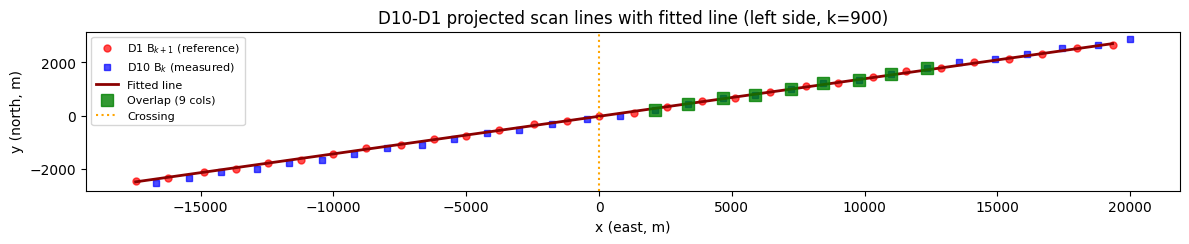

In [7]:
# Figure: Fitted reference line on the scan line (projected coordinates)
if result_left is not None:
    r = result_left
    line = r['line']
    win_cols = r['win_cols']

    # Project both scan lines onto the local tangent plane
    from find_regions import equirect_project
    x_ref, y_ref = equirect_project(lat_ref[win_cols], lon_ref[win_cols],
                                    line['lat0'], line['lon0'])
    x_meas, y_meas = equirect_project(lat_meas[win_cols], lon_meas[win_cols],
                                      line['lat0'], line['lon0'])

    # Fitted line evaluated at the reference x range
    x_fit = np.linspace(x_ref.min(), x_ref.max(), 100)
    y_fit = line['slope'] * x_fit + line['intercept']

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(x_ref, y_ref, 'o', ms=5, color='red', alpha=0.7,
            label=f'D{det_j} B$_{{k+1}}$ (reference)')
    ax.plot(x_meas, y_meas, 's', ms=5, color='blue', alpha=0.7,
            label=f'D{det_i} B$_k$ (measured)')
    ax.plot(x_fit, y_fit, '-', color='darkred', lw=2, label='Fitted line')

    # Mark overlap columns
    overlap_mask = np.isin(win_cols, r['cols'])
    ax.plot(x_meas[overlap_mask], y_meas[overlap_mask], 's', ms=8,
            color='green', alpha=0.8, label=f'Overlap ({len(r["cols"])} cols)')

    # Mark crossing
    ax.axvline(x_ref[np.argmin(np.abs(win_cols - r['center_col']))],
               color='orange', ls=':', lw=1.5, label='Crossing')

    ax.set_xlabel('x (east, m)')
    ax.set_ylabel('y (north, m)')
    ax.set_title(f'D{det_i}-D{det_j} projected scan lines with fitted line (left side, k={k})')
    ax.legend(fontsize=8)
    ax.set_aspect('equal')
    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, 'region_fitted_line.png'), dpi=150)
    plt.show()
else:
    print('No result to plot.')


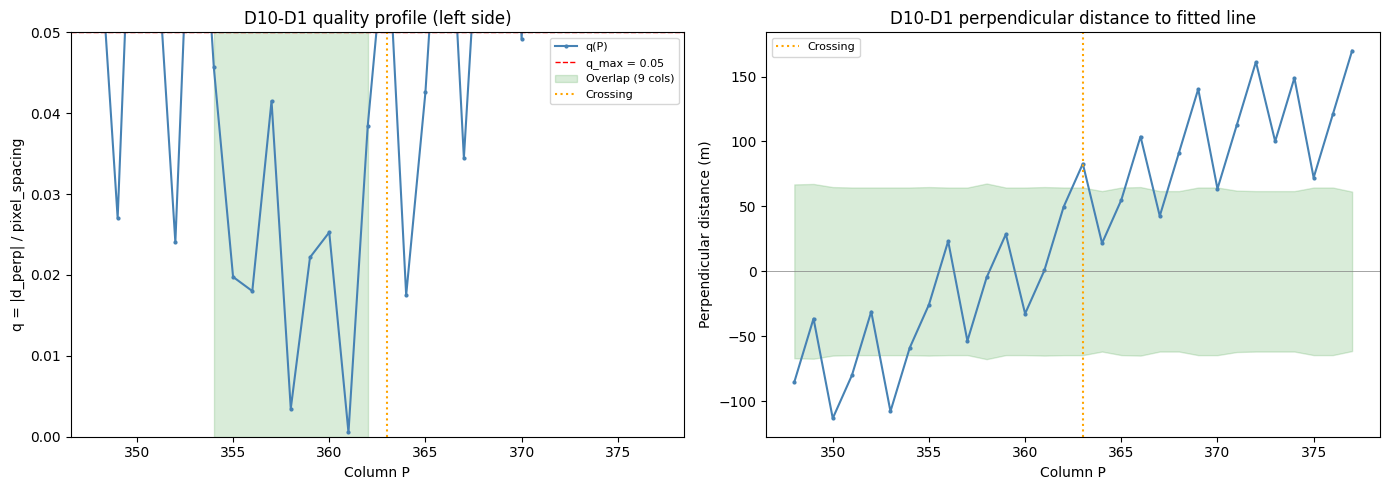

In [8]:
# Figure: Quality profile and line fit diagnostic
if result_left is not None:
    r = result_left
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left panel: quality metric q(P) over the full window
    ax = axes[0]
    ax.plot(r['win_cols'] + 1, r['q_full'], '.-', ms=4, color='steelblue', label='q(P)')
    ax.axhline(q_max, color='red', ls='--', lw=1, label=f'q_max = {q_max}')
    # Shade the overlap region
    ax.axvspan(r['cols_P'][0], r['cols_P'][-1], alpha=0.15, color='green',
               label=f'Overlap ({len(r["cols"])} cols)')
    ax.axvline(r['cross_col_P'], color='orange', ls=':', lw=1.5, label='Crossing')
    ax.set_xlabel('Column P')
    ax.set_ylabel('q = |d_perp| / pixel_spacing')
    ax.set_title(f'D{det_i}-D{det_j} quality profile (left side)')
    ax.legend(fontsize=8)
    ax.set_ylim(0, min(0.05, r['q_full'].max() * 1.2))

    # Right panel: perpendicular distance
    ax = axes[1]
    ax.plot(r['win_cols'] + 1, r['d_perp_full'], '.-', ms=4, color='steelblue')
    ax.axhline(0, color='gray', ls='-', lw=0.5)
    # Show the +/- threshold envelope
    threshold = q_max * r['ps_full']
    ax.fill_between(r['win_cols'] + 1, -threshold, threshold, alpha=0.15, color='green')
    ax.axvline(r['cross_col_P'], color='orange', ls=':', lw=1.5, label='Crossing')
    ax.set_xlabel('Column P')
    ax.set_ylabel('Perpendicular distance (m)')
    ax.set_title(f'D{det_i}-D{det_j} perpendicular distance to fitted line')
    ax.legend(fontsize=8)

    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, 'region_quality_profile.png'), dpi=150)
    plt.show()
else:
    print('No result to plot.')

## Step 3: Run All Detector Pairs

Apply the algorithm to all 12 detector pairs on both sides of nadir at boundary k.

In [9]:
# Run all detector pairs at boundary k
regions = find_regions_one_boundary(
    lat_bt[k], lon_bt[k], lat_bt[k + 1], lon_bt[k + 1],
    w=w, q_max=q_max)

print(f'Found {len(regions)} overlap regions at boundary k={k}')
print(f'{"Pair":>8s} {"Side":>6s} {"P_min":>6s} {"P_max":>6s} {"Width":>6s} '
      f'{"Cross_P":>8s} {"q_min":>8s} {"q_max":>8s}')
print('-' * 64)
for r in sorted(regions, key=lambda x: (x['det_i'], x['det_j'], x['side'])):
    print(f'D{r["det_i"]}-D{r["det_j"]}  {r["side"]:>6s} '
          f'{r["cols_P"][0]:>6d} {r["cols_P"][-1]:>6d} {len(r["cols"]):>6d} '
          f'{r["cross_col_P"]:>8.1f} {r["q"].min():>8.5f} {r["q"].max():>8.5f}')

Found 22 overlap regions at boundary k=900
    Pair   Side  P_min  P_max  Width  Cross_P    q_min    q_max
----------------------------------------------------------------
D7-D1    left     61     74     14     68.0  0.00378  0.04838
D7-D1   right   1278   1289     12   1275.0  0.00340  0.04139
D7-D2    left      1      7      7      2.0  0.01505  0.04365
D7-D2   right   1346   1354      9   1346.0  0.00425  0.04379
D8-D1    left    138    152     15    147.0  0.00062  0.04172
D8-D1   right   1201   1207      7   1193.0  0.00061  0.03420
D8-D2    left     62     75     14     69.0  0.00476  0.04914
D8-D2   right   1279   1290     12   1276.0  0.00262  0.03664
D8-D3    left      1      5      5      1.0  0.01220  0.03059
D8-D3   right   1347   1354      8   1347.0  0.00080  0.03673
D9-D1    left    237    245      9    241.0  0.00315  0.04240
D9-D1   right   1106   1110      5   1096.0  0.01293  0.04952
D9-D2    left    139    149     11    148.0  0.00175  0.04068
D9-D2   right   1202  

## Step 4: Summary Map of All Overlap Regions

Plot the scan lines near the boundary with all identified overlap regions highlighted.

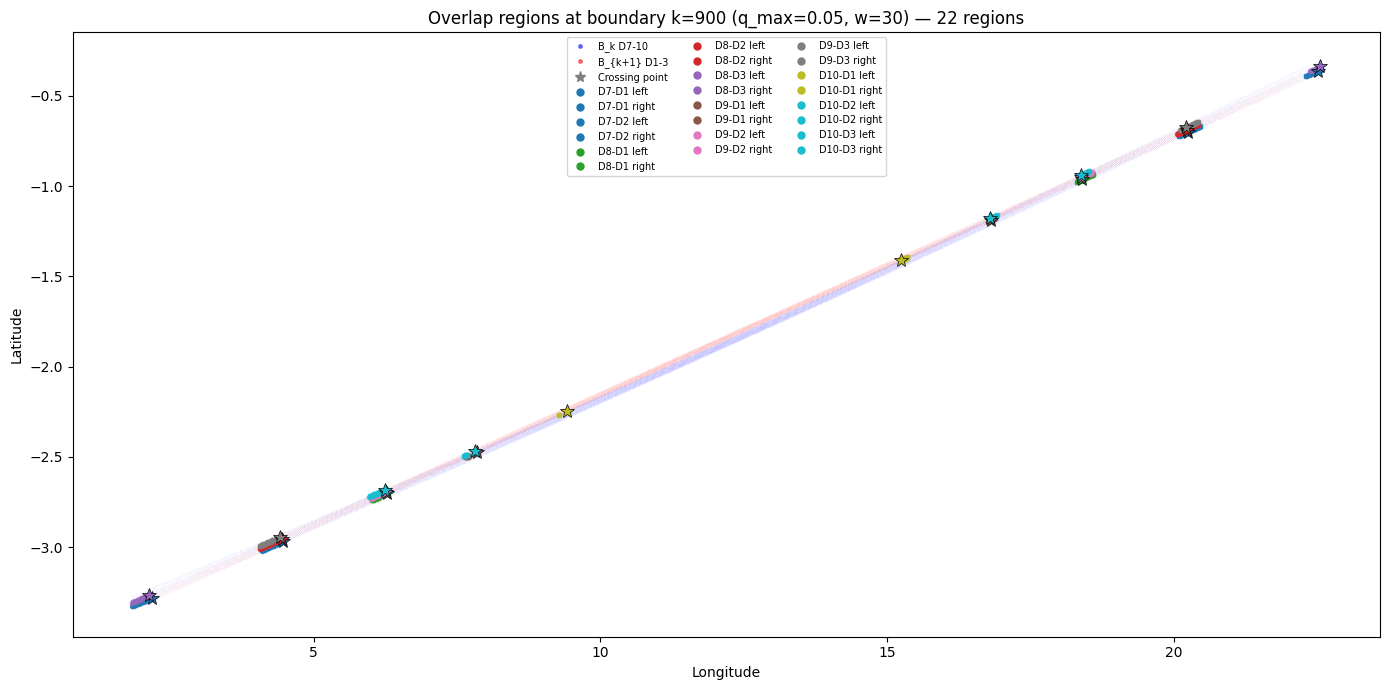

In [10]:
# Map of all overlap regions at boundary k
fig, ax = plt.subplots(figsize=(14, 7))

# Background: trailing detectors of B_k (D7-10) in blue
for d in range(6, 10):
    ax.plot(lon_bt[k, d, :], lat_bt[k, d, :],
            '.', ms=0.3, color='blue', alpha=0.2)
# Leading detectors of B_{k+1} (D1-3) in red
for d in range(0, 3):
    ax.plot(lon_bt[k + 1, d, :], lat_bt[k + 1, d, :],
            '.', ms=0.3, color='red', alpha=0.2)

# Color palette for detector pairs
colors = plt.cm.tab10(np.linspace(0, 1, len(DETECTOR_PAIRS)))
pair_colors = {pair: colors[i] for i, pair in enumerate(DETECTOR_PAIRS)}

# Highlight overlap regions
legend_entries = []
for r in regions:
    c = pair_colors[(r['det_i'], r['det_j'])]
    cols = r['cols']
    # Plot the reference scan (leading D) overlap pixels
    ax.plot(lon_bt[k + 1, r['det_j'] - 1, cols],
            lat_bt[k + 1, r['det_j'] - 1, cols],
            'o', ms=3, color=c, alpha=0.7)
    # Plot the measured scan (trailing D) overlap pixels
    ax.plot(lon_bt[k, r['det_i'] - 1, cols],
            lat_bt[k, r['det_i'] - 1, cols],
            's', ms=3, color=c, alpha=0.7)
    label = f'D{r["det_i"]}-D{r["det_j"]} {r["side"]}'
    legend_entries.append(plt.Line2D([0], [0], marker='o', color=c,
                                      ls='', ms=5, label=label))

# Add crossing points
for r in regions:
    c = pair_colors[(r['det_i'], r['det_j'])]
    cross_c = int(round(r['cross_col']))
    ax.plot(lon_bt[k + 1, r['det_j'] - 1, cross_c],
            lat_bt[k + 1, r['det_j'] - 1, cross_c],
            '*', ms=10, color=c, markeredgecolor='black', markeredgewidth=0.5)

# Legend
from matplotlib.lines import Line2D
bg_legend = [
    Line2D([0], [0], marker='.', color='blue', ls='', ms=5, alpha=0.5, label='B_k D7-10'),
    Line2D([0], [0], marker='.', color='red', ls='', ms=5, alpha=0.5, label='B_{k+1} D1-3'),
    Line2D([0], [0], marker='*', color='gray', ls='', ms=8, label='Crossing point'),
]
ax.legend(handles=bg_legend + legend_entries, fontsize=7, ncol=3, loc='upper center')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Overlap regions at boundary k={k} (q_max={q_max}, w={w}) — {len(regions)} regions')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'region_map_all.png'), dpi=150)
plt.show()

## Validation: Compare with Haversine-based matchups

Cross-check: for each overlap region, compute the Haversine distance between the
pixel centers. This should be small at the crossing and grow toward the edges.
Confirms the line-fitting approach identifies the correct overlap locations.

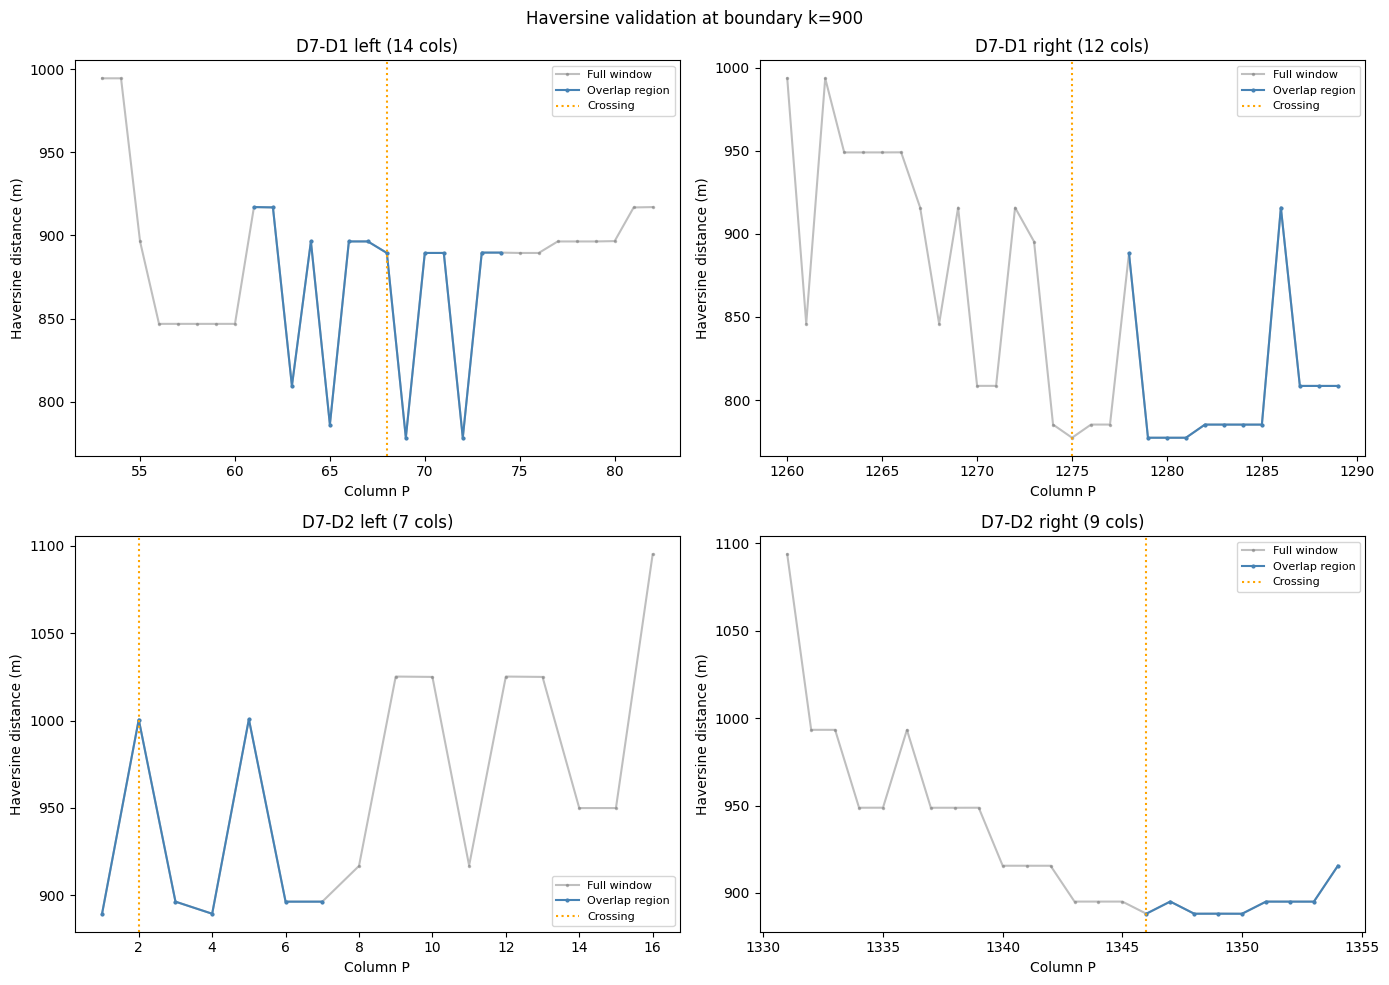

In [11]:
# For each region, compute Haversine distances and compare with q
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

# Pick up to 4 regions for detailed inspection
show_regions = regions[:min(4, len(regions))]
for idx, r in enumerate(show_regions):
    ax = axes[idx]
    cols = r['cols']
    di, dj = r['det_i'], r['det_j']

    # Haversine distance at overlap columns
    hav_dist = haversine(
        lat_bt[k, di - 1, cols], lon_bt[k, di - 1, cols],
        lat_bt[k + 1, dj - 1, cols], lon_bt[k + 1, dj - 1, cols])

    # Also compute over the full window for context
    wcols = r['win_cols']
    hav_full = haversine(
        lat_bt[k, di - 1, wcols], lon_bt[k, di - 1, wcols],
        lat_bt[k + 1, dj - 1, wcols], lon_bt[k + 1, dj - 1, wcols])

    ax.plot(wcols + 1, hav_full, '.-', ms=3, color='gray', alpha=0.5, label='Full window')
    ax.plot(cols + 1, hav_dist, '.-', ms=4, color='steelblue', label='Overlap region')
    ax.axvline(r['cross_col_P'], color='orange', ls=':', lw=1.5, label='Crossing')
    ax.set_xlabel('Column P')
    ax.set_ylabel('Haversine distance (m)')
    ax.set_title(f'D{di}-D{dj} {r["side"]} ({len(cols)} cols)')
    ax.legend(fontsize=8)

# Hide unused subplots
for idx in range(len(show_regions), 4):
    axes[idx].set_visible(False)

plt.suptitle(f'Haversine validation at boundary k={k}', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'region_haversine_validation.png'), dpi=150)
plt.show()